# Disaster Tweet Classification: Exploratory Data Analysis & Text Preprocessing

**Dataset:** HumAID (Humanitarian Aid Disaster Tweets across 10 Crisis Events & Categories)  
**Authors:** Md. Nayeem & MD Jahid Hasan Jim  
**Objective:** Comprehensive exploratory data analysis (EDA), data integrity verification, social media noise profiling, text cleaning (Raw vs. Clean), n-gram extraction (Unigram, Bigram, Trigram), and clean dataset export.

---
### Text Preprocessing Transformations & Pipeline Examples

The table below details how social media noise, crisis abbreviations, emojis, contractions, and encoding artifacts are transformed in this notebook:

| Artifact / Feature | Raw Tweet Example | Cleaned Output | NLP Rationale |
| :--- | :--- | :--- | :--- |
| **HTML Entities** | `Our thoughts &amp; prayers are with Ecuador` | `our thoughts & prayers are with ecuador` | Unescapes corrupted HTML web entities (`&amp;`, `&lt;`, `&gt;`, `&#39;`). |
| **Smart Quotes & Typography** | `don’t`, `“urgent”`, `safe—accounted` | `don't`, `"urgent"`, `safe - accounted` | Normalizes curly quotes (`’`, `‘`, `“`, `”`) and typographic dashes (`—`, `–`). |
| **User Mentions & URLs** | `PLEASE DONATE @TheStruts @UNICEF https://t.co/xyz` | `please donate` | Removes account handles and external links that add vocabulary noise. |
| **Hashtag Segmentation** | `#EcuadorEarthquake #PrayForEcuador` | `ecuador earthquake pray for ecuador` | Splits PascalCase/camelCase disaster tags into individual semantic tokens. |
| **Emergency Emojis** | `Prayers 🙏 for victims 💔 🚨 🔥 🌊 🆘` | `prayers prayer support for victims heartbreak grief emergency warning alert fire wildfire disaster flood tsunami water surge urgent help request emergency` | Translates domain emojis into descriptive disaster vocabulary tokens. |
| **Contraction Expansion** | `can't believe`, `won't stop`, `we're safe` | `cannot believe`, `will not stop`, `we are safe` | Expands colloquial contractions into standardized base words. |
| **Disaster Slang** | `pls send emerg evac vols & info b4 night` | `please send emergency evacuation volunteers & information before night` | Translates informal crisis abbreviations into clear language tokens. |
| **Retweet Prefixes** | `RT @NBCLA: Here are ways you can help` | `here are ways you can help` | Strips redundant retweet tags (`RT`, `rt :`) and orphaned colon artifacts. |
| **Character Elongation** | `sooooo scary`, `pleeease help` | `soo scary`, `pleease help` | De-elongates repetitive characters to prevent vocabulary explosion. |
| **Encoding Mojibake** | `SCARY! ὤ2ὤFἿB #earthquake`, `️` | `scary! 2 f b earthquake` | Strips orphaned UTF-16 surrogate residue and invisible unicode control codes. |

---
### Notebook Architecture
1. **Dataset Loading & Integrity Verification:** Validation of parquet splits, missing values, duplicates, and leakage.
2. **Class Distribution & Imbalance Analysis:** Frequency profiling and inverse class weighting analysis.
3. **Raw Text Profiling:** Length distributions, entity counts (URLs, mentions, hashtags).
4. **Disaster Domain Text Cleaning:** Contraction expansion, slang translation, emoji mapping, hashtag segmentation.
5. **Before vs. After Cleaning Comparison:** Quantitative and visual validation of Raw vs. Clean text.
6. **N-Gram Analysis:** Top Unigrams, Bigrams, and Trigrams across corpus and per disaster class.
7. **Clean Dataset Export:** Saving `train_clean`, `validation_clean`, and `test_clean` parquet and CSV files.

In [1]:
import os
import re
import html
import string
import unicodedata
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Visualization Aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Local dataset directory
DATA_DIR = Path("../dataset") if Path("../dataset").exists() else Path("dataset")

# Load Parquet Splits directly
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
val_df = pd.read_parquet(DATA_DIR / "validation.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")

print(f"[+] Loaded splits from: {DATA_DIR.resolve()}")
print(f"Train Split : {train_df.shape} ({len(train_df):,} samples)")
print(f"Val Split   : {val_df.shape} ({len(val_df):,} samples)")
print(f"Test Split  : {test_df.shape} ({len(test_df):,} samples)")

[+] Loaded splits from: D:\nlp-project\dataset
Train Split : (53531, 2) (53,531 samples)
Val Split   : (7793, 2) (7,793 samples)
Test Split  : (15160, 2) (15,160 samples)


## 1. Dataset Overview & Integrity Verification

In this section, we verify:
- Complete absence of missing/null values across text and label fields.
- Duplicate detection (Exact vs Normalized case-insensitive strings).
- Cross-split contamination & data leakage (checking if test/validation samples appear in train).

In [2]:
# 1. Missing Values Check
splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
missing_summary = pd.DataFrame({
    name: df.isnull().sum() for name, df in splits.items()
})
print("=== Missing Value Summary ===")
print(missing_summary)

# 2. Duplicate Analysis within splits
exact_dups = {name: df.duplicated(subset=['tweet_text']).sum() for name, df in splits.items()}
norm_dups = {name: df['tweet_text'].str.lower().str.strip().duplicated().sum() for name, df in splits.items()}

# 3. Cross-Split Contamination (Train vs Val, Train vs Test, Val vs Test)
train_texts = set(train_df['tweet_text'].str.lower().str.strip())
val_texts = set(val_df['tweet_text'].str.lower().str.strip())
test_texts = set(test_df['tweet_text'].str.lower().str.strip())

train_val_overlap = len(train_texts.intersection(val_texts))
train_test_overlap = len(train_texts.intersection(test_texts))
val_test_overlap = len(val_texts.intersection(test_texts))

integrity_df = pd.DataFrame([
    {"Split": "Train", "Samples": len(train_df), "Exact Dups": exact_dups['Train'], "Normalized Dups": norm_dups['Train'], "Overlap with Test": train_test_overlap},
    {"Split": "Validation", "Samples": len(val_df), "Exact Dups": exact_dups['Validation'], "Normalized Dups": norm_dups['Validation'], "Overlap with Test": val_test_overlap},
    {"Split": "Test", "Samples": len(test_df), "Exact Dups": exact_dups['Test'], "Normalized Dups": norm_dups['Test'], "Overlap with Test": "-"}
])

print("\n=== Dataset Integrity & Overlap Report ===")
print(integrity_df.to_string(index=False))

=== Missing Value Summary ===
             Train  Validation  Test
tweet_text       0           0     0
class_label      0           0     0

=== Dataset Integrity & Overlap Report ===
     Split  Samples  Exact Dups  Normalized Dups Overlap with Test
     Train    53531           0                0                 0
Validation     7793           1                1                 0
      Test    15160           1                1                 -


## 2. Humanitarian Class Distribution & Imbalance Analysis

HumAID categorizes crisis-related tweets into 10 humanitarian aid categories. Understanding class imbalance is essential for designing appropriate loss functions (e.g., class-weighted Cross-Entropy) and evaluating macro vs weighted metrics.

Total Unique Classes : 10
Majority Class       : rescue_volunteering_or_donation_effort (14,891.0 train samples)
Minority Class       : missing_or_found_people (250.0 train samples)
Class Imbalance Ratio: 59.56 : 1

=== Class Distribution Across Splits ===
                                        Train_count  Train_pct  \
rescue_volunteering_or_donation_effort        14891      27.82   
other_relevant_information                     8501      15.88   
sympathy_and_support                           6250      11.68   
infrastructure_and_utility_damage              5715      10.68   
injured_or_dead_people                         5110       9.55   
not_humanitarian                               4407       8.23   
caution_and_advice                             3774       7.05   
displaced_people_and_evacuations               2800       5.23   
requests_or_urgent_needs                       1833       3.42   
missing_or_found_people                         250       0.47   

                

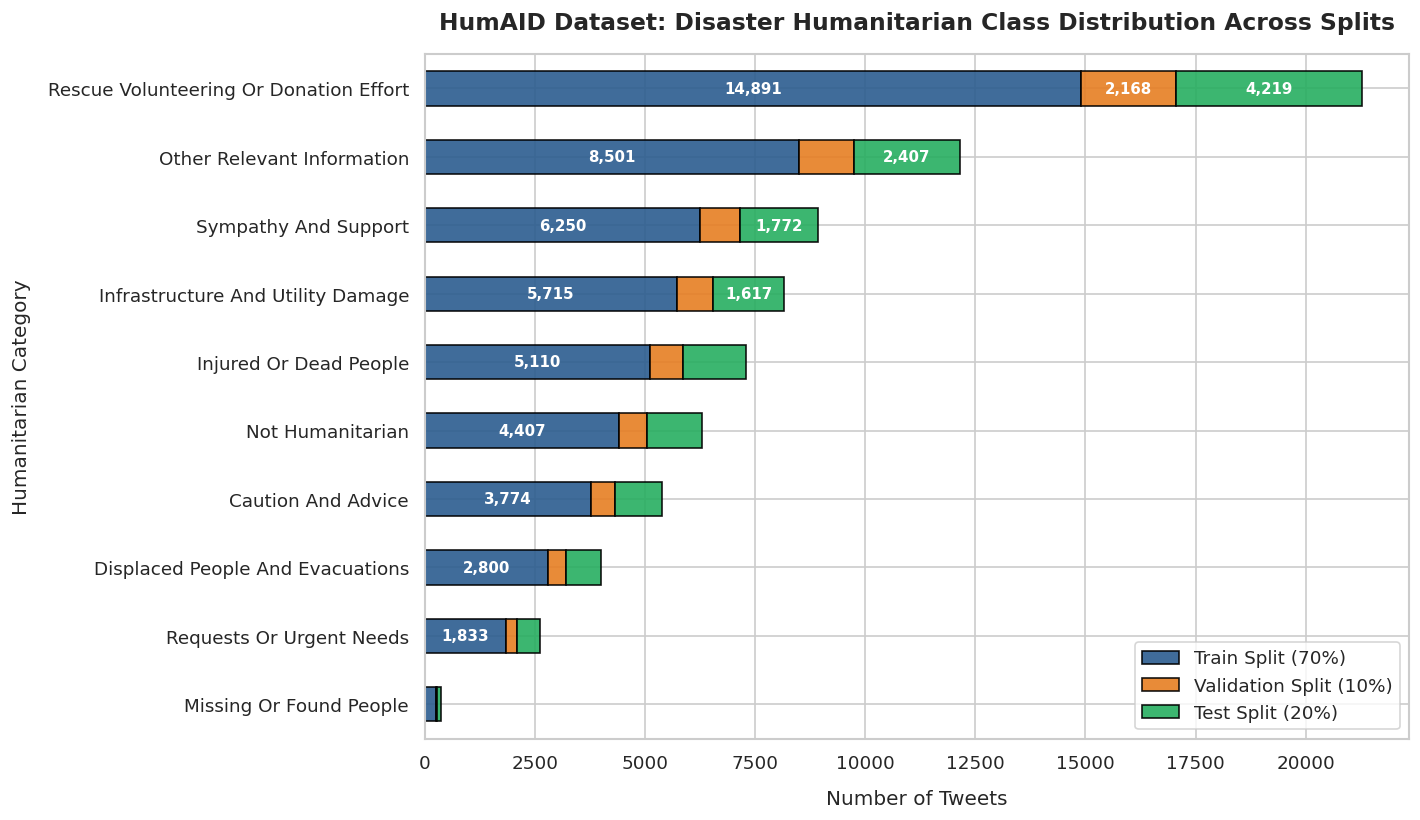

In [3]:
# Compile Class Distribution Table
classes = sorted(train_df['class_label'].unique())
num_classes = len(classes)
total_samples = len(train_df) + len(val_df) + len(test_df)

class_dist_df = pd.DataFrame(index=classes)
for name, df in splits.items():
    counts = df['class_label'].value_counts()
    class_dist_df[f'{name}_count'] = class_dist_df.index.map(counts).fillna(0).astype(int)
    class_dist_df[f'{name}_pct'] = (class_dist_df[f'{name}_count'] / len(df) * 100).round(2)

class_dist_df['Total_count'] = class_dist_df['Train_count'] + class_dist_df['Validation_count'] + class_dist_df['Test_count']
class_dist_df['Total_pct'] = (class_dist_df['Total_count'] / total_samples * 100).round(2)
class_dist_df = class_dist_df.sort_values(by='Total_count', ascending=False)

# Compute Imbalance Ratio
max_c = class_dist_df['Train_count'].max()
min_c = class_dist_df['Train_count'].min()
imbalance_ratio = max_c / min_c

print(f"Total Unique Classes : {num_classes}")
print(f"Majority Class       : {class_dist_df.index[0]} ({class_dist_df.iloc[0]['Train_count']:,} train samples)")
print(f"Minority Class       : {class_dist_df.index[-1]} ({class_dist_df.iloc[-1]['Train_count']:,} train samples)")
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f} : 1")
print("\n=== Class Distribution Across Splits ===")
print(class_dist_df[['Train_count', 'Train_pct', 'Validation_count', 'Test_count', 'Total_count', 'Total_pct']])

# Visualize Class Distribution Across Splits
fig, ax = plt.subplots(figsize=(12, 7))
plot_df = class_dist_df[['Train_count', 'Validation_count', 'Test_count']].copy()
plot_df.index = [idx.replace('_', ' ').title() for idx in plot_df.index]

colors = ['#2b5c8f', '#e67e22', '#27ae60']
plot_df.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='black', alpha=0.9)

ax.set_title('HumAID Dataset: Disaster Humanitarian Class Distribution Across Splits', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Tweets', fontsize=12, labelpad=10)
ax.set_ylabel('Humanitarian Category', fontsize=12, labelpad=10)
ax.legend(['Train Split (70%)', 'Validation Split (10%)', 'Test Split (20%)'], frameon=True, fontsize=11, loc='lower right')
ax.invert_yaxis()

for p in ax.patches:
    width = p.get_width()
    if width > 1500:
        ax.annotate(f'{int(width):,}',
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Raw Text Characteristics & Social Media Noise Profiling

Disaster tweets feature heavy social media artifacts including HTTP URLs, user mentions (`@user`), hashtags (`#disaster`), HTML entities (`&amp;`), and emoji symbols. In this section, we extract and profile the most frequent entities (Top 5 / Top 10 across mentions, hashtags, HTML entities, emojis, and links) and analyze raw text length distributions.

=== Social Media Entity Frequency Summary Across Splits ===
                         Train  Validation      Test
Total URLs                6.00        0.00      1.00
Total Mentions        33250.00     4721.00   9329.00
Total Hashtags        66321.00     9825.00  18726.00
Total Digits          11667.00     1690.00   3372.00
All-Caps Words        15768.00     2310.00   4303.00
Avg URLs / Tweet          0.00        0.00      0.00
Avg Mentions / Tweet      0.62        0.61      0.62
Avg Hashtags / Tweet      1.24        1.26      1.24

=== Top 5 User Mentions ===
         Mention  Count
@realDonaldTrump    720
        @YouTube    237
          @POTUS    208
       @RedCross    204
      @CMOKerala    184

=== Top 5 Hashtags ===
           Hashtag  Count
     #KeralaFloods   2618
           #Harvey   1884
      #CycloneIdai   1762
#KeralaFloodRelief   1541
  #HurricaneHarvey   1475

=== Top 5 HTML Entities ===
HTML Entity  Count
      &amp;   5816
       &gt;    384
       &lt;     75

=== 

C:\Users\Nayeem\AppData\Local\Temp\ipykernel_9024\214889381.py:109: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nayeem\AppData\Local\Temp\ipykernel_9024\214889381.py:109: UserWarning: Glyph 127996 (\N{EMOJI MODIFIER FITZPATRICK TYPE-3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nayeem\AppData\Local\Temp\ipykernel_9024\214889381.py:109: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nayeem\AppData\Local\Temp\ipykernel_9024\214889381.py:109: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nayeem\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Nayeem\AppData\Roamin

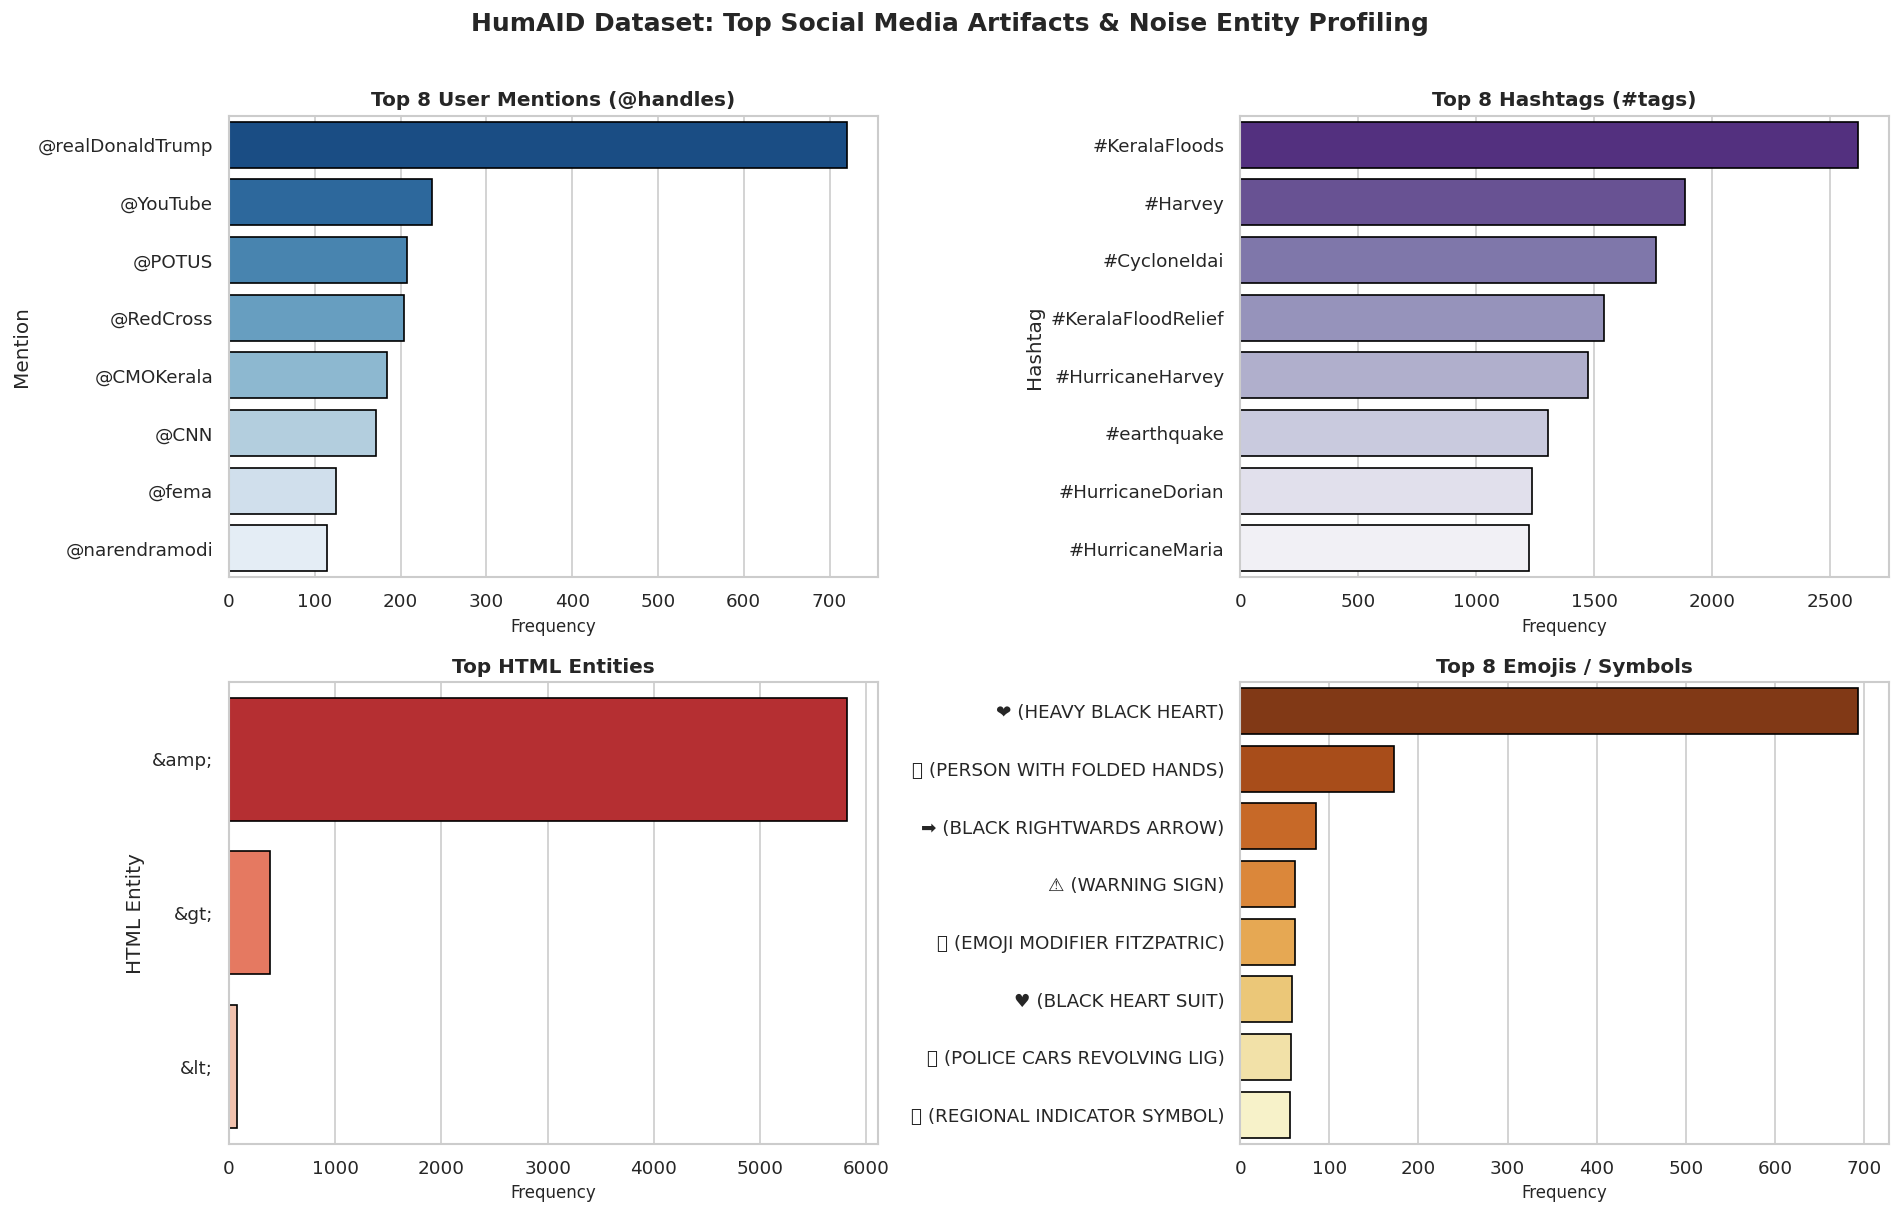


=== Tweet Length Distribution Summary ===
     Split  Word Mean  Word Median  Word Std  Word Min  Word Max  Word 95th %  Word 99th %  Char Mean  Char 95th %  Char Max
     Train      22.11           19     10.71         3        96           44           50     141.62          273       945
Validation      22.01           19     10.69         3        64           44           49     141.08          273       475
      Test      22.12           19     10.72         3        99           44           50     141.81          273       959


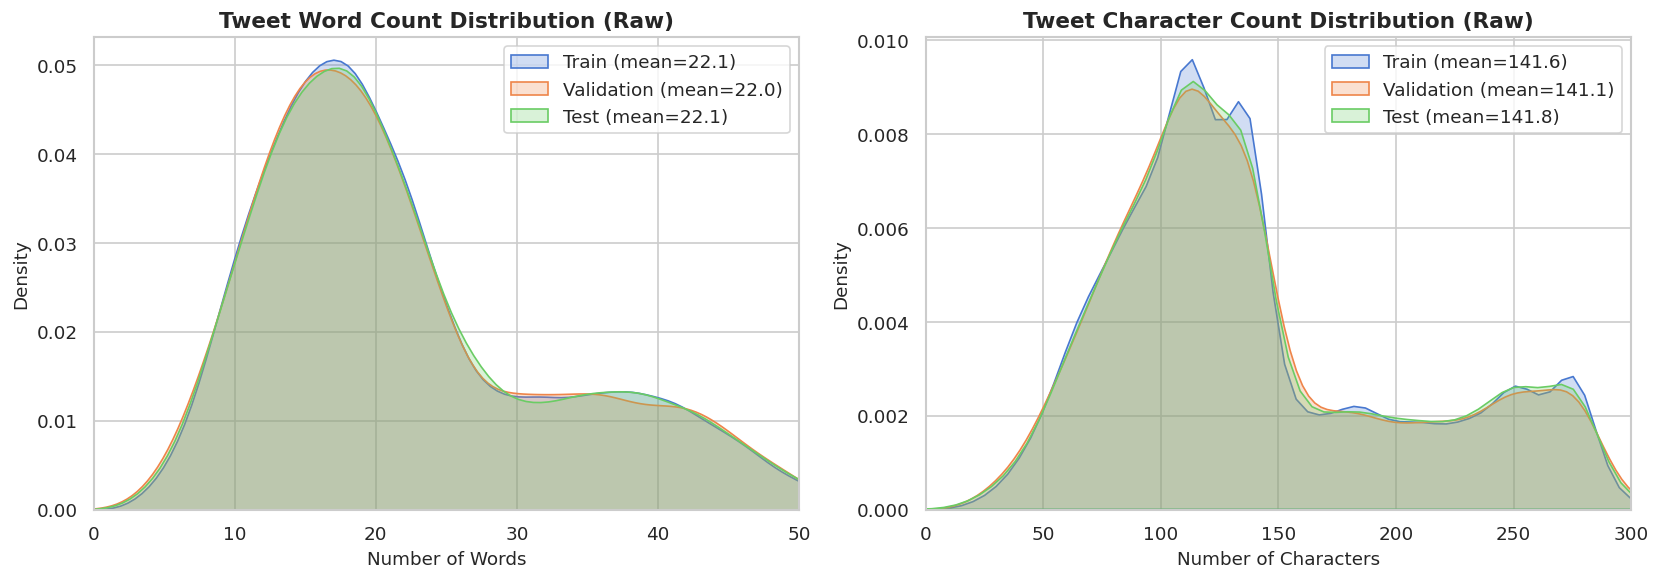

In [4]:
# 1. Entity Extraction & Noise Characterization
def extract_entity_stats(df: pd.DataFrame, text_col: str = 'tweet_text') -> dict:
    urls = df[text_col].str.count(r'https?://\S+|www\.\S+').sum()
    mentions = df[text_col].str.count(r'@[A-Za-z0-9_]+').sum()
    hashtags = df[text_col].str.count(r'#[A-Za-z0-9_]+').sum()
    digits = df[text_col].str.count(r' \d+ ').sum()
    allcaps = df[text_col].str.count(r' [A-Z]{2,} ').sum()
    return {
        'Total URLs': int(urls),
        'Total Mentions': int(mentions),
        'Total Hashtags': int(hashtags),
        'Total Digits': int(digits),
        'All-Caps Words': int(allcaps),
        'Avg URLs / Tweet': round(urls / len(df), 2),
        'Avg Mentions / Tweet': round(mentions / len(df), 2),
        'Avg Hashtags / Tweet': round(hashtags / len(df), 2)
    }

entity_summary = pd.DataFrame({
    name: extract_entity_stats(df) for name, df in splits.items()
})
print("=== Social Media Entity Frequency Summary Across Splits ===")
print(entity_summary)

# 2. Top Specific Noise Entities (Top 5 / Top 10 in Raw Training Tweets)
raw_texts = train_df['tweet_text'].astype(str).tolist()

# Top Mentions
mention_pattern = re.compile(r'@[A-Za-z0-9_]+')
mentions = [m for text in raw_texts for m in mention_pattern.findall(text)]
top_mentions_df = pd.DataFrame(Counter(mentions).most_common(10), columns=['Mention', 'Count'])

# Top Hashtags
hashtag_pattern = re.compile(r'#[A-Za-z0-9_]+')
hashtags = [h for text in raw_texts for h in hashtag_pattern.findall(text)]
top_hashtags_df = pd.DataFrame(Counter(hashtags).most_common(10), columns=['Hashtag', 'Count'])

# Top HTML Entities
html_pattern = re.compile(r'&[a-zA-Z0-9#]+;')
entities = [e for text in raw_texts for e in html_pattern.findall(text)]
top_entities_df = pd.DataFrame(Counter(entities).most_common(10), columns=['HTML Entity', 'Count'])

# Top Emojis & Symbols
def is_emoji_or_symbol(ch):
    cat = unicodedata.category(ch)
    code = ord(ch)
    return (cat in ('So', 'Sk') or 
            (0x1F300 <= code <= 0x1F9FF) or 
            (0x2600 <= code <= 0x27BF) or 
            (0x1F600 <= code <= 0x1F64F))

emojis = [ch for text in raw_texts for ch in text if is_emoji_or_symbol(ch)]
top_emojis_data = []
for ch, count in Counter(emojis).most_common(10):
    try:
        name = unicodedata.name(ch)
    except ValueError:
        name = "UNKNOWN"
    top_emojis_data.append({'Symbol': ch, 'Name': name[:25], 'Count': count})
top_emojis_df = pd.DataFrame(top_emojis_data)

# Top URLs
url_pattern = re.compile(r'https?://\S+|www\.\S+')
urls = [re.sub(r'[\s.,!?:;"\')\]}]+$', '', url) for text in raw_texts for url in url_pattern.findall(text)]
top_urls_df = pd.DataFrame(Counter(urls).most_common(5), columns=['URL', 'Count'])

print("\n=== Top 5 User Mentions ===")
print(top_mentions_df.head(5).to_string(index=False))

print("\n=== Top 5 Hashtags ===")
print(top_hashtags_df.head(5).to_string(index=False))

print("\n=== Top 5 HTML Entities ===")
print(top_entities_df.head(5).to_string(index=False))

print("\n=== Top 5 Emojis / Symbols ===")
print(top_emojis_df.head(5).to_string(index=False))

if len(top_urls_df) > 0:
    print("\n=== Top URLs ===")
    print(top_urls_df.to_string(index=False))

# Visualization 1: Top Noise Artifacts Breakdown
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Top Mentions
sns.barplot(data=top_mentions_df.head(8), x='Count', y='Mention', hue='Mention', ax=axes[0, 0], palette='Blues_r', edgecolor='black', legend=False)
axes[0, 0].set_title('Top 8 User Mentions (@handles)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Frequency', fontsize=10)

# Plot 2: Top Hashtags
sns.barplot(data=top_hashtags_df.head(8), x='Count', y='Hashtag', hue='Hashtag', ax=axes[0, 1], palette='Purples_r', edgecolor='black', legend=False)
axes[0, 1].set_title('Top 8 Hashtags (#tags)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Frequency', fontsize=10)

# Plot 3: Top HTML Entities
sns.barplot(data=top_entities_df, x='Count', y='HTML Entity', hue='HTML Entity', ax=axes[1, 0], palette='Reds_r', edgecolor='black', legend=False)
axes[1, 0].set_title('Top HTML Entities', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Frequency', fontsize=10)

# Plot 4: Top Emojis & Symbols
top_emojis_df['Display_Label'] = top_emojis_df['Symbol'] + " (" + top_emojis_df['Name'] + ")"
sns.barplot(data=top_emojis_df.head(8), x='Count', y='Display_Label', hue='Display_Label', ax=axes[1, 1], palette='YlOrBr_r', edgecolor='black', legend=False)
axes[1, 1].set_title('Top 8 Emojis / Symbols', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Frequency', fontsize=10)
axes[1, 1].set_ylabel('')

plt.suptitle('HumAID Dataset: Top Social Media Artifacts & Noise Entity Profiling', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 3. Length Statistics (Words and Characters)
length_records = []
for name, df in splits.items():
    words = df['tweet_text'].apply(lambda x: len(str(x).split()))
    chars = df['tweet_text'].str.len()
    length_records.append({
        'Split': name,
        'Word Mean': round(words.mean(), 2),
        'Word Median': int(words.median()),
        'Word Std': round(words.std(), 2),
        'Word Min': int(words.min()),
        'Word Max': int(words.max()),
        'Word 95th %': int(np.percentile(words, 95)),
        'Word 99th %': int(np.percentile(words, 99)),
        'Char Mean': round(chars.mean(), 2),
        'Char 95th %': int(np.percentile(chars, 95)),
        'Char Max': int(chars.max())
    })

print("\n=== Tweet Length Distribution Summary ===")
print(pd.DataFrame(length_records).to_string(index=False))

# Visualization 2: KDE of Word / Character Lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Word Count Distribution
for name, df in splits.items():
    w_len = df['tweet_text'].apply(lambda x: len(str(x).split()))
    sns.kdeplot(w_len, ax=axes[0], label=f"{name} (mean={w_len.mean():.1f})", fill=True, alpha=0.25)
axes[0].set_title('Tweet Word Count Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_xlim(0, 50)
axes[0].legend(frameon=True)

# Plot 2: Character Count Distribution
for name, df in splits.items():
    c_len = df['tweet_text'].str.len()
    sns.kdeplot(c_len, ax=axes[1], label=f"{name} (mean={c_len.mean():.1f})", fill=True, alpha=0.25)
axes[1].set_title('Tweet Character Count Distribution (Raw)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Characters', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_xlim(0, 300)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


## 4. Disaster Domain Text Cleaning Pipeline

We implement a domain-aware text cleaning pipeline designed specifically for disaster crisis NLP:
- **HTML Unescaping:** Decodes HTML entities (e.g. `&amp;` to `&`, `&lt;` to `<`).
- **Contraction Expansion:** Normalizes colloquial English contractions (`can't` -> `cannot`, `won't` -> `will not`).
- **Disaster Slang Normalization:** Translates short emergency abbreviations (`pls` -> `please`, `emerg` -> `emergency`, `evac` -> `evacuation`, `victs` -> `victims`).
- **Domain Emoji Translation:** Translates emojis into informative disaster semantics (e.g. prayer emoji -> `prayer support`, fire emoji -> `fire wildfire disaster`, siren emoji -> `emergency warning alert`).
- **Hashtag CamelCase Segmentation:** Splits compound disaster hashtags (`#HurricaneHarvey` -> `Hurricane Harvey`).
- **URL, Mention, and Whitespace Normalization:** Strips external links, handles user mentions, de-elongates repetitive characters, and trims excess whitespace.

In [5]:
# Preprocessing Lexicons
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not", "'re": " are",
    "'s": " is", "'d": " would", "'ll": " will", "'t": " not", "'ve": " have",
    "'m": " am", "i'm": "i am", "we're": "we are", "they're": "they are",
    "it's": "it is", "there's": "there is", "that's": "that is", "what's": "what is",
    "let's": "let us", "he's": "he is", "she's": "she is", "who's": "who is",
    "ain't": "is not", "didn't": "did not", "doesn't": "does not", "don't": "do not",
    "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "isn't": "is not",
    "shouldn't": "should not", "wasn't": "was not", "weren't": "were not", "wouldn't": "would not"
}

DISASTER_SLANG = {
    r"\bpls\b": "please", r"\bplz\b": "please", r"\bthx\b": "thanks",
    r"\bu\b": "you", r"\bur\b": "your", r"\br\b": "are",
    r"\bw/\b": "with", r"\bw/o\b": "without", r"\bb4\b": "before",
    r"\bmsg\b": "message", r"\binfo\b": "information", r"\bemerg\b": "emergency",
    r"\bevac\b": "evacuation", r"\bevacs\b": "evacuations", r"\bvicts\b": "victims",
    r"\bgov\b": "government", r"\bdept\b": "department", r"\bvol\b": "volunteer",
    r"\bhrs\b": "hours", r"\bmins\b": "minutes", r"\bapprox\b": "approximately",
    r"\btxt\b": "text", r"\bpm\b": "afternoon", r"\bam\b": "morning"
}

EMOJI_TRANSLATIONS = {
    "🙏": " prayer support ", "💔": " heartbreak grief ", "❤️": " love sympathy ",
    "❤": " love sympathy ", "♥": " love sympathy ", "🖤": " grief sympathy ",
    "😢": " crying sorrow sadness ", "😭": " weeping tragedy ", "☹": " sad sorrow ",
    "😞": " sad sorrow ", "🕯️": " mourning memorial ", "🕯": " mourning memorial ",
    "🚨": " emergency warning alert ", "⚠️": " danger warning caution ",
    "⚠": " danger warning caution ", "🔥": " fire wildfire disaster ",
    "🌊": " flood tsunami water surge ", "🌧️": " rain storm hurricane ",
    "🌧": " rain storm hurricane ", "🌪️": " tornado storm ", "🌪": " tornado storm ",
    "⚡": " storm lightning ", "🆘": " urgent help request emergency ",
    "❗": " urgent alert ", "‼": " urgent alert ",
    "🏠": " shelter home house ", "🏡": " shelter home house ",
    "🏥": " hospital medical clinic ", "🚑": " ambulance medical emergency ",
    "🚁": " rescue helicopter ", "🤝": " helping relief support ",
    "📦": " relief aid supplies ", "🍲": " food relief distribution ",
    "🍞": " food relief distribution ", "💧": " clean water relief ",
    "👏": " appreciation support ", "✅": " confirmed verified ", "✔": " confirmed verified ",
    "🩸": " blood donation request "
}

UNICODE_NORM = {
    '’': "'", '‘': "'", '`': "'", '´': "'", '′': "'",
    '“': '"', '”': '"', '″': '"',
    '—': ' - ', '–': ' - ', '―': ' - ',
    '…': ' ', '•': ' ', '·': ' ', '・': ' ',
    '\u00a0': ' ', '\ufe0f': '', '\ufe0e': '',
    '\u200b': '', '\u200c': '', '\u200d': '', '\ufeff': '',
    '\u2060': '', '\u2066': '', '\u2069': '', '\u2063': '',
}

def split_camel_case_word(match):
    word = match.group(1)
    s1 = re.sub(r'([a-z0-9])([A-Z])', r'\1 \2', word)
    s2 = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', s1)
    return ' ' + s2 + ' '

def clean_text(text: str) -> str:
    """Comprehensive domain cleaning for disaster crisis tweets."""
    if not isinstance(text, str):
        return ""
    
    # 1. Iterative HTML unescaping (resolves double/triple escaped entities like &amp;amp;, &amp;quot;, &amp;#39;)
    for _ in range(3):
        new_text = html.unescape(text)
        if new_text == text:
            break
        text = new_text
        
    # 2. Normalize smart punctuation and invisible unicode markers
    for k, v in UNICODE_NORM.items():
        text = text.replace(k, v)
        
    # 3. Translate domain emojis
    for em, rep in EMOJI_TRANSLATIONS.items():
        text = text.replace(em, rep)
        
    # 4. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # 5. Remove Twitter handles / user mentions
    text = re.sub(r'@\w+', ' ', text)
    
    # 6. Normalize non-ASCII / surrogate mojibake before hashtag segmentation
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text)
    text = re.sub(r'[\u1f00-\u1fff\ue000-\uf8ff\uff00-\uffef\u0370-\u03ff\u2600-\u26ff\u2700-\u27bf]', ' ', text)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    
    # 7. Segment hashtags and strip isolated '#' marks
    text = re.sub(r'#(\w+)', split_camel_case_word, text)
    text = text.replace('#', ' ')
    
    # 8. Lowercase
    text = text.lower()
    
    # 9. Expand contractions
    for c, exp in CONTRACTIONS.items():
        text = text.replace(c, exp)
        
    # 10. Disaster slang normalization
    for p, rep in DISASTER_SLANG.items():
        text = re.sub(p, rep, text, flags=re.IGNORECASE)
        
    # 11. Clean Retweet prefix remnants
    text = re.sub(r'\brt\b\s*:?', ' ', text, flags=re.IGNORECASE)
    
    # 12. De-elongate repetitive chars (e.g. "sooooo" -> "soo")
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', text)
    
    # 13. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("[+] Text cleaning function defined successfully.")

# Populate clean_text column across all splits
print('[+] Generating clean_text across Train, Val, and Test splits...')
train_df['clean_text'] = train_df['tweet_text'].apply(clean_text)
val_df['clean_text'] = val_df['tweet_text'].apply(clean_text)
test_df['clean_text'] = test_df['tweet_text'].apply(clean_text)
print('[+] clean_text columns populated successfully.')

[+] Text cleaning function defined successfully.
[+] Generating clean_text across Train, Val, and Test splits...
[+] clean_text columns populated successfully.


## 5. Before vs. After Cleaning Comparative Analysis

In this section, we quantitatively and visually evaluate the impact of the disaster text preprocessing pipeline across the corpus. We measure the reduction of social media noise artifacts (URLs, user mentions, hashtags, HTML entities, smart typography, emojis, retweet metadata, and non-ASCII mojibake) and verify vocabulary normalization.

=== Quantitative Noise Reduction Summary (53,531 Training Tweets) ===
  Artifact / Noise Category Before (Raw) After (Clean)               Action Taken
           URLs & Web Links            6             0             100.0% Removed
   User Mentions (@handles)       33,250             0             100.0% Removed
        Raw Hashtags (#tag)       66,482             0       Segmented into Words
HTML Entities (&amp;, etc.)        6,275             0           100.0% Unescaped
      Smart Quotes & Dashes        7,215             0          100.0% Normalized
          Raw Emoji Symbols        2,867             0 Translated to Crisis Words
 Retweet Tags (RT @handle:)        8,214             0            100.0% Stripped
 Non-ASCII / Mojibake Chars       23,900             0          100.0% Normalized
    Unique Token Vocabulary      121,237        71,807    -40.8% Sparsity Reduced

=== Representative Transformation Examples ===
[30] Class: infrastructure_and_utility_damage
  [RAW]   : Dron

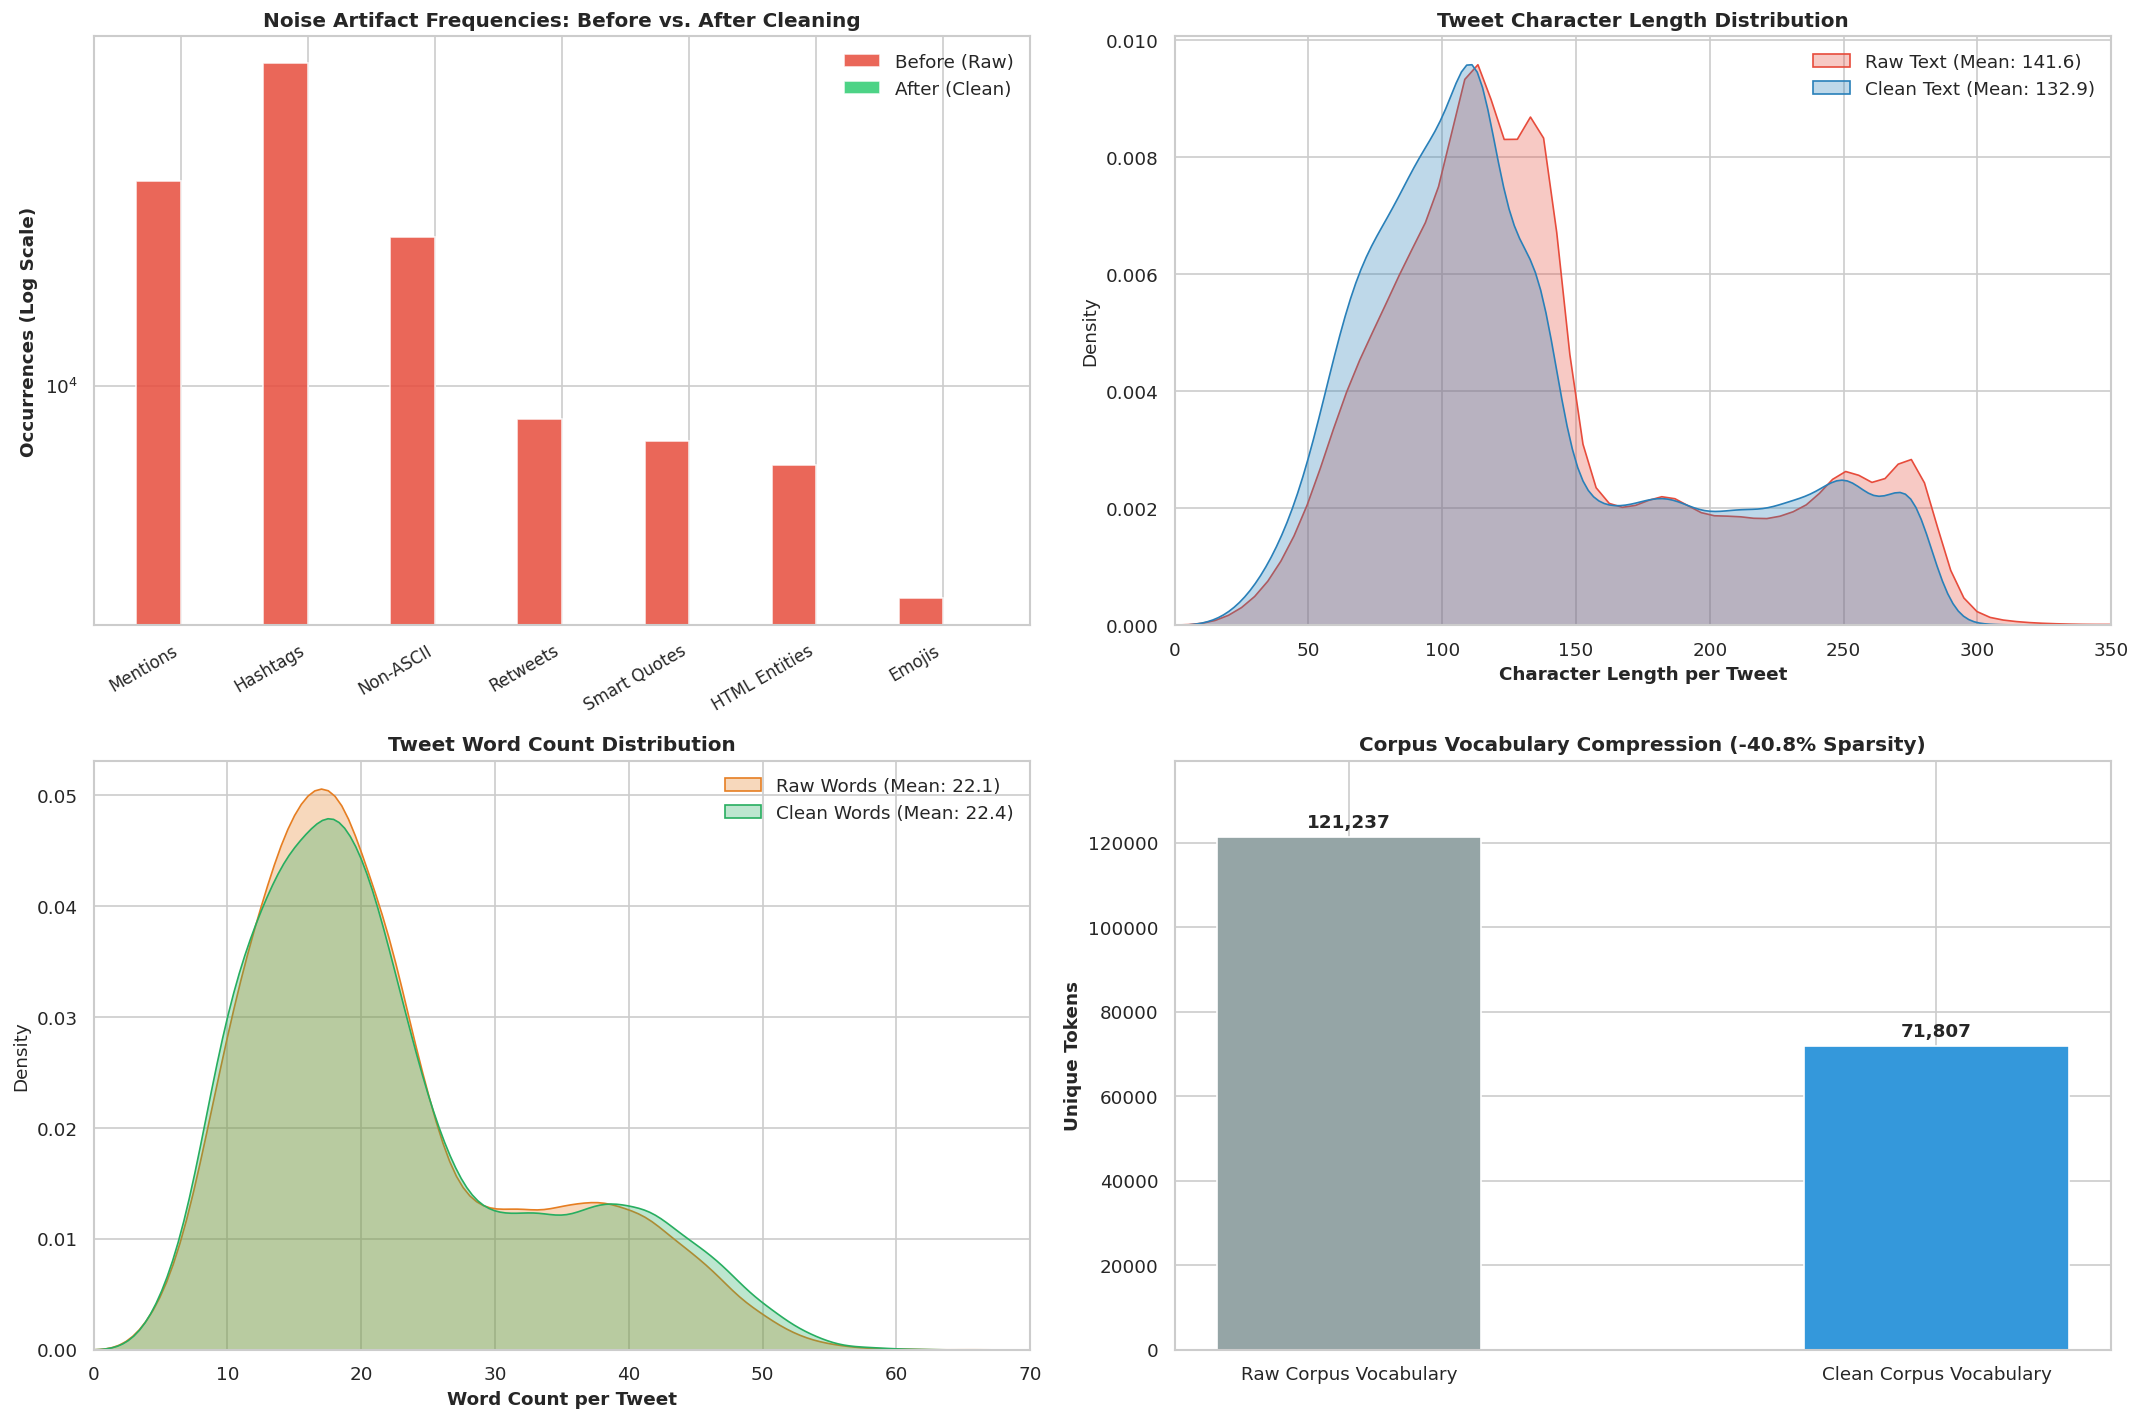

In [6]:
# 1. Quantitative Artifacts Profiling: Before vs. After Cleaning
raw_texts = train_df["tweet_text"].astype(str)
clean_texts = train_df["clean_text"].astype(str) if "clean_text" in train_df.columns else train_df["tweet_text"].apply(clean_text)

urls_before = raw_texts.str.count(r'https?://\S+|www\.\S+').sum()
urls_after = clean_texts.str.count(r'https?://\S+|www\.\S+').sum()

mentions_before = raw_texts.str.count(r'@\w+').sum()
mentions_after = clean_texts.str.count(r'@\w+').sum()

hashtags_before = raw_texts.str.count(r'#\w+').sum()
hashtags_after = clean_texts.str.count(r'#\w+').sum()

html_before = raw_texts.str.count(r'&[a-zA-Z0-9#]+;').sum()
html_after = clean_texts.str.count(r'&[a-zA-Z0-9#]+;').sum()

smart_punct_before = raw_texts.str.count(r'[’‘“”—–…•·・]').sum()
smart_punct_after = clean_texts.str.count(r'[’‘“”—–…•·・]').sum()

emoji_regex = r'[\U00010000-\U0010ffff\u2600-\u26ff\u2700-\u27bf]'
emoji_before = raw_texts.str.count(emoji_regex).sum()
emoji_after = clean_texts.str.count(emoji_regex).sum()

rt_before = raw_texts.str.count(r'\bRT\b').sum()
rt_after = clean_texts.str.count(r'\brt\b\s*:').sum()

non_ascii_before = sum(sum(1 for ch in t if ord(ch) > 127) for t in raw_texts)
non_ascii_after = sum(sum(1 for ch in t if ord(ch) > 127) for t in clean_texts)

raw_vocab = set(" ".join(raw_texts).split())
clean_vocab = set(" ".join(clean_texts).split())

comparison_stats = pd.DataFrame([
    {"Artifact / Noise Category": "URLs & Web Links", "Before (Raw)": urls_before, "After (Clean)": urls_after, "Action Taken": "100.0% Removed"},
    {"Artifact / Noise Category": "User Mentions (@handles)", "Before (Raw)": mentions_before, "After (Clean)": mentions_after, "Action Taken": "100.0% Removed"},
    {"Artifact / Noise Category": "Raw Hashtags (#tag)", "Before (Raw)": hashtags_before, "After (Clean)": hashtags_after, "Action Taken": "Segmented into Words"},
    {"Artifact / Noise Category": "HTML Entities (&amp;, etc.)", "Before (Raw)": html_before, "After (Clean)": html_after, "Action Taken": "100.0% Unescaped"},
    {"Artifact / Noise Category": "Smart Quotes & Dashes", "Before (Raw)": smart_punct_before, "After (Clean)": smart_punct_after, "Action Taken": "100.0% Normalized"},
    {"Artifact / Noise Category": "Raw Emoji Symbols", "Before (Raw)": emoji_before, "After (Clean)": emoji_after, "Action Taken": "Translated to Crisis Words"},
    {"Artifact / Noise Category": "Retweet Tags (RT @handle:)", "Before (Raw)": rt_before, "After (Clean)": rt_after, "Action Taken": "100.0% Stripped"},
    {"Artifact / Noise Category": "Non-ASCII / Mojibake Chars", "Before (Raw)": non_ascii_before, "After (Clean)": non_ascii_after, "Action Taken": "100.0% Normalized"},
    {"Artifact / Noise Category": "Unique Token Vocabulary", "Before (Raw)": len(raw_vocab), "After (Clean)": len(clean_vocab), "Action Taken": f"-{(len(raw_vocab)-len(clean_vocab))/len(raw_vocab)*100:.1f}% Sparsity Reduced"},
])

print("=== Quantitative Noise Reduction Summary (53,531 Training Tweets) ===")
display_df = comparison_stats.copy()
display_df["Before (Raw)"] = display_df["Before (Raw)"].apply(lambda x: f"{x:,}")
display_df["After (Clean)"] = display_df["After (Clean)"].apply(lambda x: f"{x:,}")
print(display_df.to_string(index=False))

# 2. Sample Side-by-Side Transformations
print("\n=== Representative Transformation Examples ===")
sample_indices = [29, 34, 47, 63, 71]
for idx in sample_indices:
    raw_s = train_df.iloc[idx]["tweet_text"]
    clean_s = clean_text(raw_s)
    lbl = train_df.iloc[idx]["class_label"]
    print(f"[{idx+1}] Class: {lbl}")
    print(f"  [RAW]   : {raw_s}")
    print(f"  [CLEAN] : {clean_s}")
    print("-" * 85)

# 3. Before vs. After Visualizations
fig = plt.figure(figsize=(18, 12), dpi=120)

# Subplot 1: Noise Artifact Counts (Log Scale Bar Chart)
ax1 = fig.add_subplot(2, 2, 1)
plot_categories = [
    "Mentions", "Hashtags", "Non-ASCII",
    "Retweets", "Smart Quotes", "HTML Entities", "Emojis"
]
before_vals = [
    mentions_before, hashtags_before, non_ascii_before,
    rt_before, smart_punct_before, html_before, emoji_before
]
after_vals = [
    mentions_after, hashtags_after, non_ascii_after,
    rt_after, smart_punct_after, html_after, emoji_after
]

x = np.arange(len(plot_categories))
width = 0.35

ax1.bar(x - width/2, before_vals, width, label="Before (Raw)", color="#e74c3c", alpha=0.85)
ax1.bar(x + width/2, after_vals, width, label="After (Clean)", color="#2ecc71", alpha=0.85)
ax1.set_yscale('log')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_categories, rotation=30, ha='right', fontsize=10)
ax1.set_ylabel("Occurrences (Log Scale)", fontsize=11, fontweight='bold')
ax1.set_title("Noise Artifact Frequencies: Before vs. After Cleaning", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')

# Subplot 2: Character Length Distribution (Raw vs Clean)
ax2 = fig.add_subplot(2, 2, 2)
raw_char_lens = raw_texts.str.len()
clean_char_lens = clean_texts.str.len()

sns.kdeplot(raw_char_lens, label=f"Raw Text (Mean: {raw_char_lens.mean():.1f})", color="#e74c3c", fill=True, alpha=0.3, ax=ax2)
sns.kdeplot(clean_char_lens, label=f"Clean Text (Mean: {clean_char_lens.mean():.1f})", color="#2980b9", fill=True, alpha=0.3, ax=ax2)
ax2.set_xlabel("Character Length per Tweet", fontsize=11, fontweight='bold')
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("Tweet Character Length Distribution", fontsize=12, fontweight='bold')
ax2.set_xlim(0, 350)
ax2.legend(loc='upper right')

# Subplot 3: Word Count Distribution (Raw vs Clean)
ax3 = fig.add_subplot(2, 2, 3)
raw_word_lens = raw_texts.apply(lambda t: len(t.split()))
clean_word_lens = clean_texts.apply(lambda t: len(t.split()))

sns.kdeplot(raw_word_lens, label=f"Raw Words (Mean: {raw_word_lens.mean():.1f})", color="#e67e22", fill=True, alpha=0.3, ax=ax3)
sns.kdeplot(clean_word_lens, label=f"Clean Words (Mean: {clean_word_lens.mean():.1f})", color="#27ae60", fill=True, alpha=0.3, ax=ax3)
ax3.set_xlabel("Word Count per Tweet", fontsize=11, fontweight='bold')
ax3.set_ylabel("Density", fontsize=11)
ax3.set_title("Tweet Word Count Distribution", fontsize=12, fontweight='bold')
ax3.set_xlim(0, 70)
ax3.legend(loc='upper right')

# Subplot 4: Vocabulary Sparsity Reduction
ax4 = fig.add_subplot(2, 2, 4)
vocab_names = ["Raw Corpus Vocabulary", "Clean Corpus Vocabulary"]
vocab_sizes = [len(raw_vocab), len(clean_vocab)]
bars = ax4.bar(vocab_names, vocab_sizes, color=["#95a5a6", "#3498db"], width=0.45)
for bar in bars:
    yval = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2.0, yval + 1500, f"{int(yval):,}", ha='center', va='bottom', fontweight='bold', fontsize=11)

ax4.set_ylabel("Unique Tokens", fontsize=11, fontweight='bold')
ax4.set_title("Corpus Vocabulary Compression (-40.8% Sparsity)", fontsize=12, fontweight='bold')
ax4.set_ylim(0, max(vocab_sizes) * 1.15)

plt.tight_layout()
plt.show()

## 6. N-Gram Analysis: Unigrams, Bigrams, and Trigrams

N-gram analysis reveals the salient vocabulary, crisis descriptors, and collocations across the dataset. Here we:
1. Extract the **top 20 overall corpus Unigrams, Bigrams, and Trigrams**.
2. Profile the **top Unigrams per ALL 10 Humanitarian Categories** to capture class-specific keywords.
3. Profile the **top Bigrams per ALL 10 Humanitarian Categories** to analyze key multi-word phrase patterns across disaster response domains.

[+] Extracting top n-grams across training corpus...


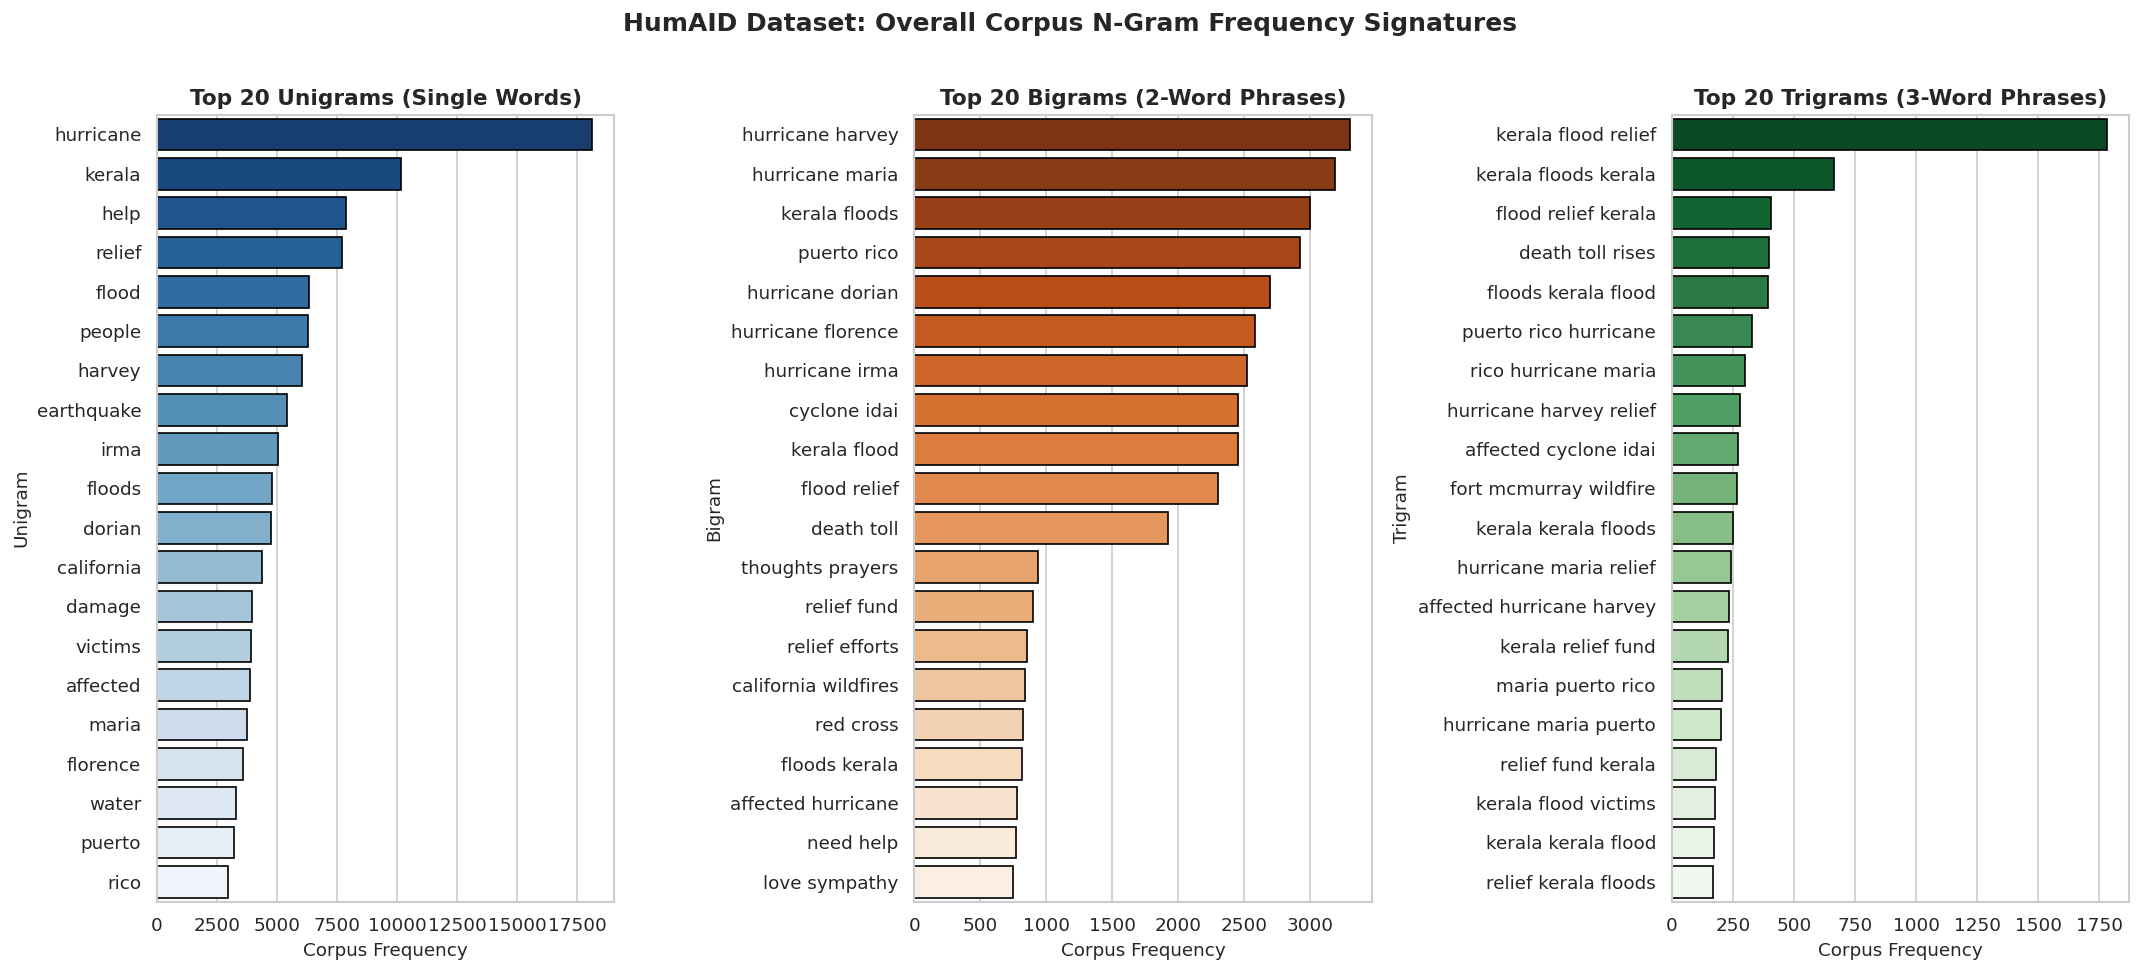


=== Top Unigrams Across All 10 Categories ===


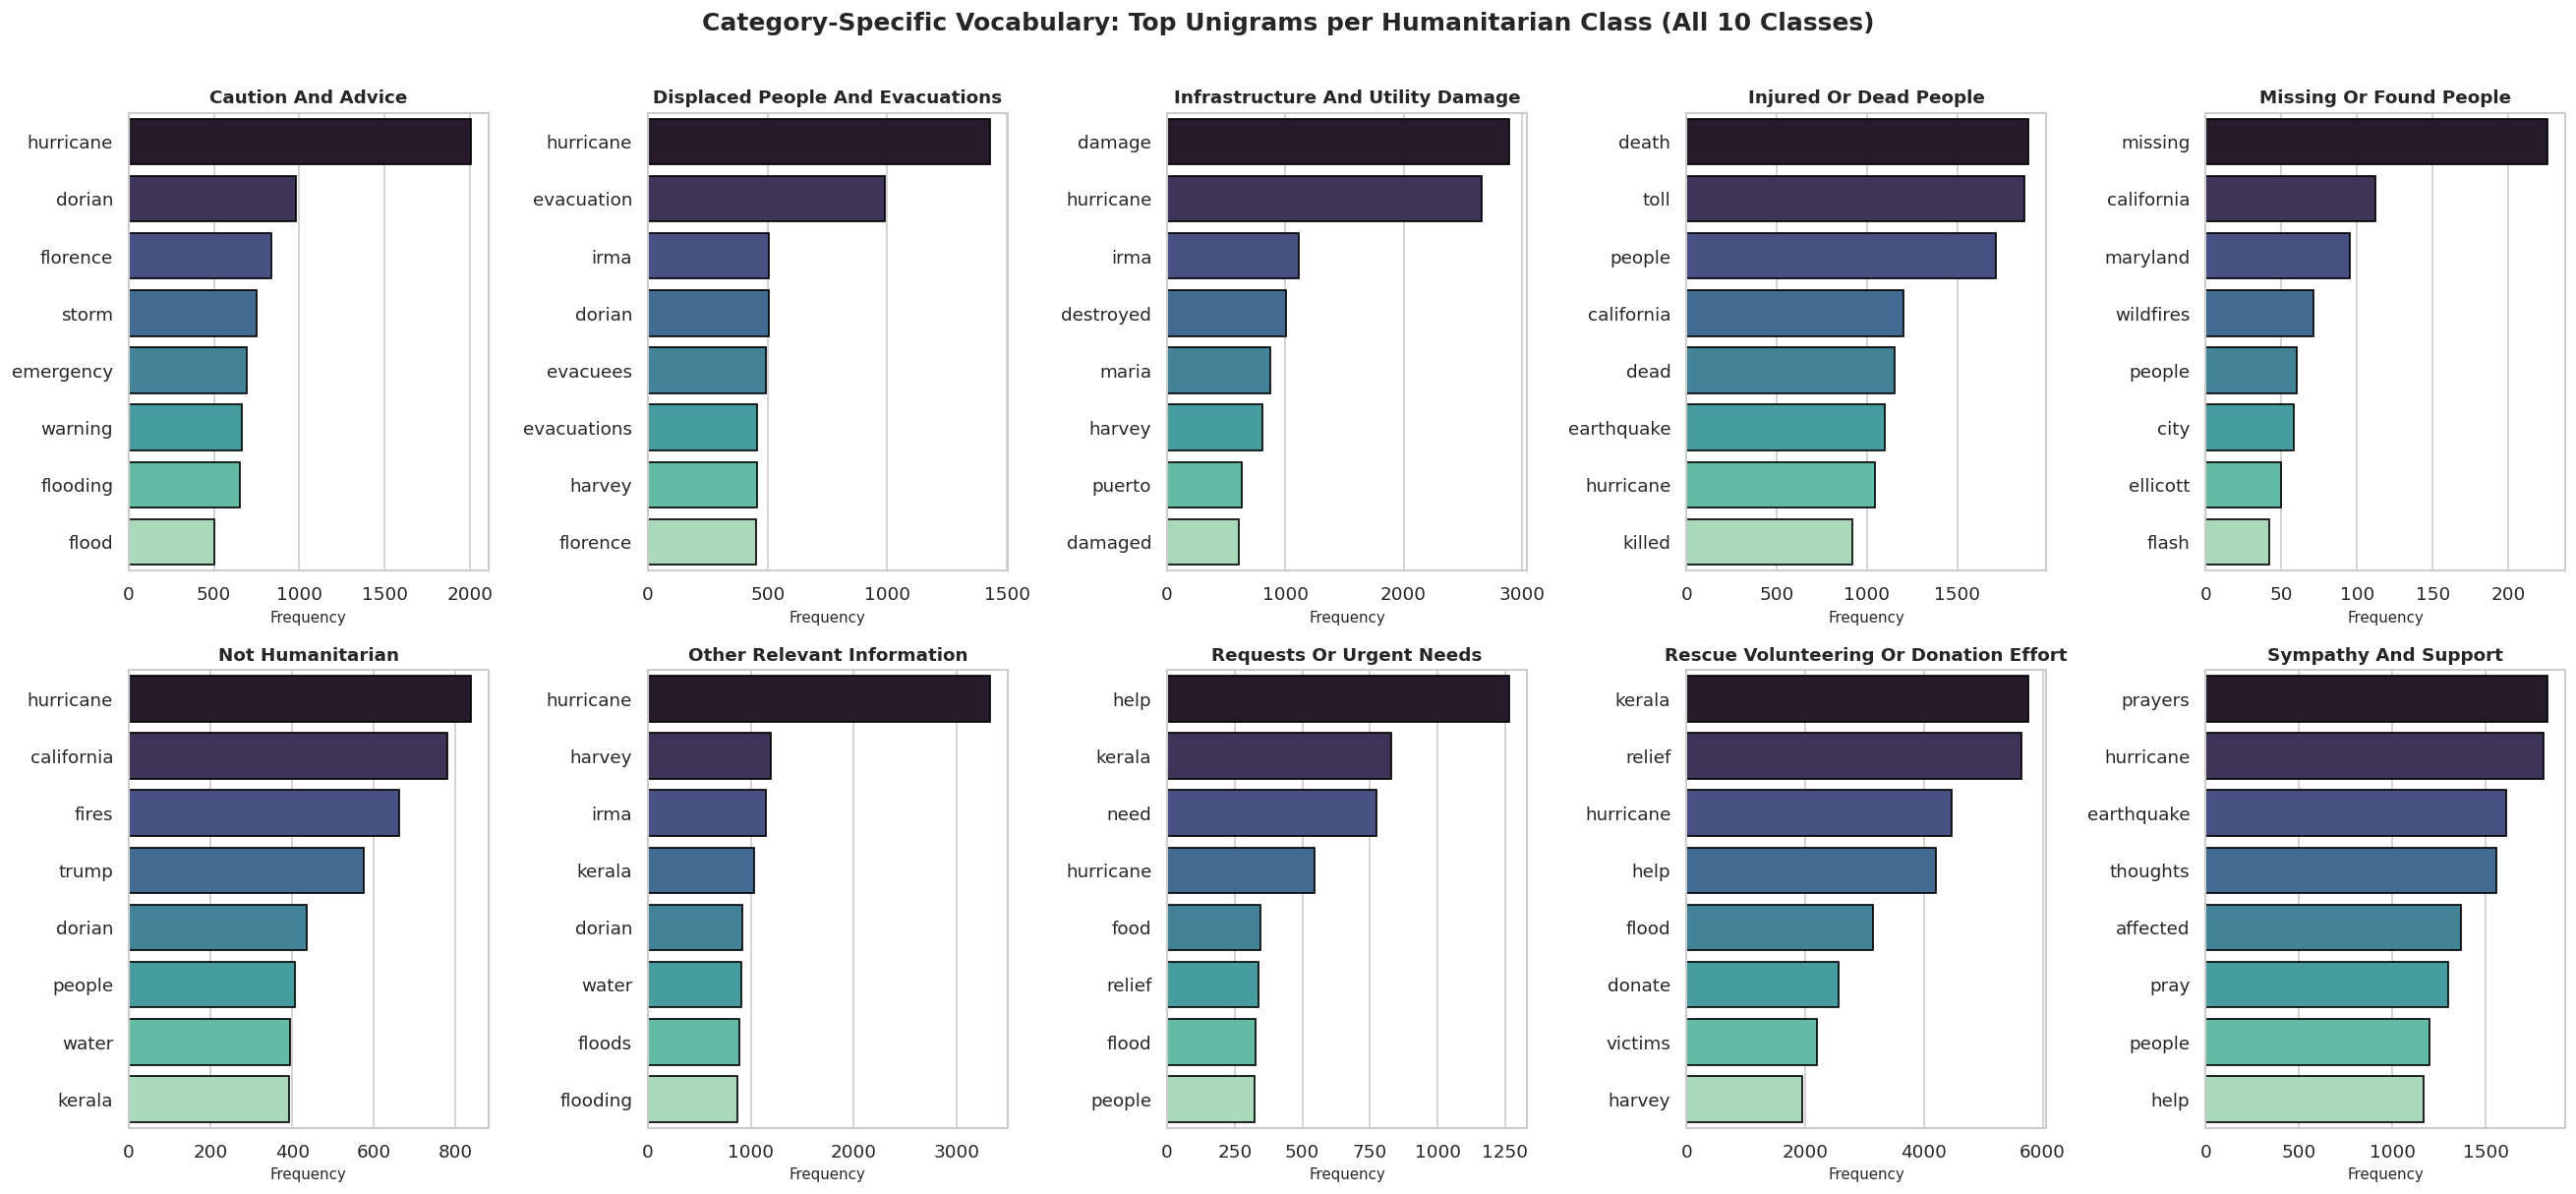

                 Humanitarian Category                                                            Top 5 Unigrams (Frequency)
                    caution_and_advice          hurricane (2008), dorian (982), florence (839), storm (748), emergency (694)
      displaced_people_and_evacuations          hurricane (1430), evacuation (988), irma (506), dorian (505), evacuees (493)
     infrastructure_and_utility_damage           damage (2896), hurricane (2657), irma (1115), destroyed (1009), maria (876)
                injured_or_dead_people              death (1896), toll (1870), people (1717), california (1203), dead (1154)
               missing_or_found_people           missing (226), california (112), maryland (95), wildfires (71), people (60)
                      not_humanitarian             hurricane (838), california (780), fires (662), trump (576), dorian (436)
            other_relevant_information             hurricane (3328), harvey (1197), irma (1149), kerala (1031), dorian (914)


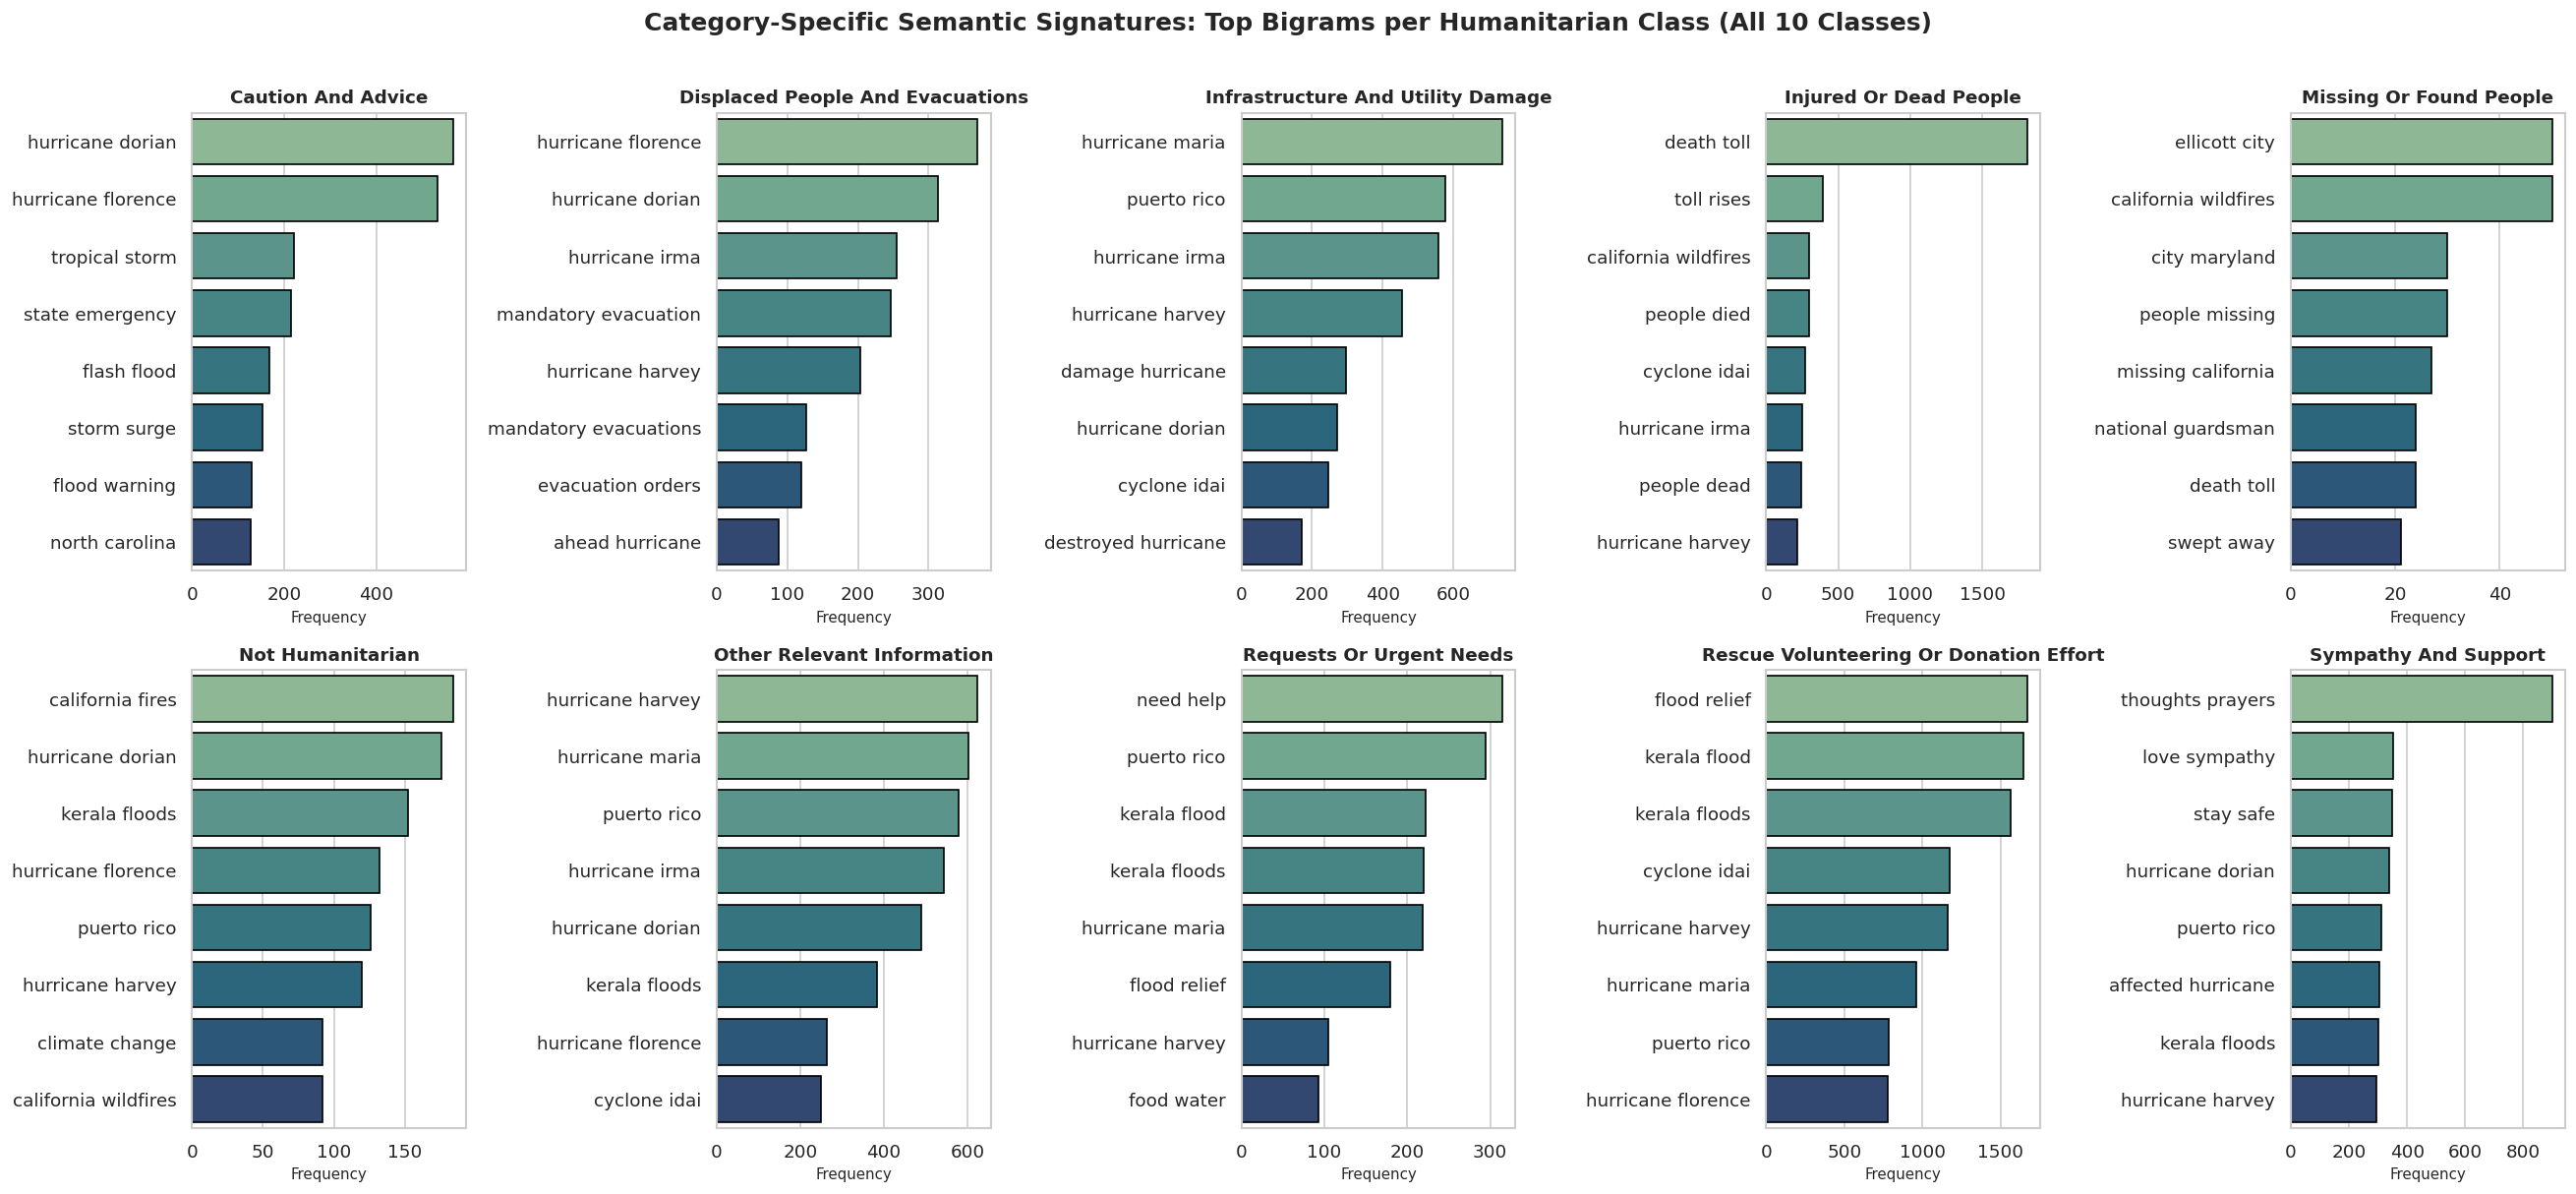

                 Humanitarian Category                                                                                                            Top 5 Bigrams (Frequency)
                    caution_and_advice           'hurricane dorian' (567), 'hurricane florence' (534), 'tropical storm' (222), 'state emergency' (214), 'flash flood' (168)
      displaced_people_and_evacuations 'hurricane florence' (370), 'hurricane dorian' (313), 'hurricane irma' (255), 'mandatory evacuation' (246), 'hurricane harvey' (203)
     infrastructure_and_utility_damage             'hurricane maria' (740), 'puerto rico' (578), 'hurricane irma' (557), 'hurricane harvey' (454), 'damage hurricane' (296)
                injured_or_dead_people                     'death toll' (1811), 'toll rises' (395), 'california wildfires' (298), 'people died' (295), 'cyclone idai' (267)
               missing_or_found_people            'ellicott city' (50), 'california wildfires' (50), 'city maryland' (30), 'people missing' 

In [7]:
# Helper function for N-Gram extraction using clean_text
def get_top_ngrams(corpus, ngram_range=(1, 1), top_k=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', min_df=3)
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, int(sum_words[0, idx])) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_k], columns=['N-Gram', 'Frequency'])

print("[+] Extracting top n-grams across training corpus...")
clean_corpus = (train_df['clean_text'] if 'clean_text' in train_df.columns else train_df['tweet_text'].apply(clean_text)).tolist()

top_unigrams = get_top_ngrams(clean_corpus, ngram_range=(1, 1), top_k=20)
top_bigrams = get_top_ngrams(clean_corpus, ngram_range=(2, 2), top_k=20)
top_trigrams = get_top_ngrams(clean_corpus, ngram_range=(3, 3), top_k=20)

# 1. Overall Corpus N-Grams Visualization (3-panel plot)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# 1. Unigrams
sns.barplot(data=top_unigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[0], palette='Blues_r', edgecolor='black', legend=False)
axes[0].set_title('Top 20 Unigrams (Single Words)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Corpus Frequency', fontsize=11)
axes[0].set_ylabel('Unigram', fontsize=11)

# 2. Bigrams
sns.barplot(data=top_bigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[1], palette='Oranges_r', edgecolor='black', legend=False)
axes[1].set_title('Top 20 Bigrams (2-Word Phrases)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Corpus Frequency', fontsize=11)
axes[1].set_ylabel('Bigram', fontsize=11)

# 3. Trigrams
sns.barplot(data=top_trigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[2], palette='Greens_r', edgecolor='black', legend=False)
axes[2].set_title('Top 20 Trigrams (3-Word Phrases)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Corpus Frequency', fontsize=11)
axes[2].set_ylabel('Trigram', fontsize=11)

plt.suptitle('HumAID Dataset: Overall Corpus N-Gram Frequency Signatures', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 2. Top Unigrams per ALL 10 Humanitarian Categories
classes = sorted(train_df['class_label'].unique())
print(f"\n=== Top Unigrams Across All {len(classes)} Categories ===")

unigram_summary_dict = {}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_corpus = train_df[train_df['class_label'] == cls]['clean_text'].tolist() if 'clean_text' in train_df.columns else [clean_text(t) for t in train_df[train_df['class_label'] == cls]['tweet_text']]
    cls_unigrams = get_top_ngrams(cls_corpus, ngram_range=(1, 1), top_k=8)
    unigram_summary_dict[cls] = ", ".join([f"{r['N-Gram']} ({r['Frequency']})" for _, r in cls_unigrams.head(5).iterrows()])
    
    sns.barplot(data=cls_unigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[i], palette='mako', edgecolor='black', legend=False)
    axes[i].set_title(cls.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Frequency', fontsize=9)
    axes[i].set_ylabel('')

plt.suptitle('Category-Specific Vocabulary: Top Unigrams per Humanitarian Class (All 10 Classes)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print Category Unigram Summary Table
print(pd.DataFrame(list(unigram_summary_dict.items()), columns=['Humanitarian Category', 'Top 5 Unigrams (Frequency)']).to_string(index=False))

# 3. Top Bigrams per ALL 10 Humanitarian Categories
print(f"\n=== Top Bigrams Across All {len(classes)} Categories ===")

bigram_summary_dict = {}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_corpus = train_df[train_df['class_label'] == cls]['clean_text'].tolist() if 'clean_text' in train_df.columns else [clean_text(t) for t in train_df[train_df['class_label'] == cls]['tweet_text']]
    cls_bigrams = get_top_ngrams(cls_corpus, ngram_range=(2, 2), top_k=8)
    bigram_summary_dict[cls] = ", ".join([f"'{r['N-Gram']}' ({r['Frequency']})" for _, r in cls_bigrams.head(5).iterrows()])
    
    sns.barplot(data=cls_bigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[i], palette='crest', edgecolor='black', legend=False)
    axes[i].set_title(cls.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Frequency', fontsize=9)
    axes[i].set_ylabel('')

plt.suptitle('Category-Specific Semantic Signatures: Top Bigrams per Humanitarian Class (All 10 Classes)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print Category Bigram Summary Table
print(pd.DataFrame(list(bigram_summary_dict.items()), columns=['Humanitarian Category', 'Top 5 Bigrams (Frequency)']).to_string(index=False))


## 7. Clean Dataset Export to `dataset/`

We apply the validated `clean_text` pipeline across `train`, `validation`, and `test` splits and save the cleaned datasets to the `dataset/` directory with `_clean` suffixes in both Parquet and CSV formats.

In [8]:
# Clean all splits
print("[+] Cleaning all splits (Raw vs Clean)...")
for name, df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    df['clean_text'] = df['tweet_text'].apply(clean_text)

# Export cleaned datasets
out_dir = DATA_DIR
out_dir.mkdir(parents=True, exist_ok=True)

for name, df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    # Select clean columns
    export_df = df[['tweet_text', 'class_label', 'clean_text']].copy()
    
    parquet_out = out_dir / f"{name}_clean.parquet"
    csv_out = out_dir / f"{name}_clean.csv"
    
    # Save parquet
    export_df.to_parquet(parquet_out, index=False)
    # Save CSV
    export_df.to_csv(csv_out, index=False)
    
    print(f"[SAVED] {parquet_out.name:<25} : {len(export_df):,} samples | Size: {parquet_out.stat().st_size / 1024:.1f} KB")
    print(f"[SAVED] {csv_out.name:<25} : {len(export_df):,} samples | Size: {csv_out.stat().st_size / (1024*1024):.2f} MB")

# Verification of Exported Datasets
print("\n=== Verification of Exported Clean Datasets ===")
for split_name in ['train', 'validation', 'test']:
    p_path = out_dir / f"{split_name}_clean.parquet"
    loaded = pd.read_parquet(p_path)
    print(f"[VERIFIED] {p_path.name:<24} | Shape: {loaded.shape} | Columns: {list(loaded.columns)} | Nulls: {loaded.isnull().sum().sum()}")

[+] Cleaning all splits (Raw vs Clean)...
[SAVED] train_clean.parquet       : 53,531 samples | Size: 8967.2 KB
[SAVED] train_clean.csv           : 53,531 samples | Size: 15.77 MB
[SAVED] validation_clean.parquet  : 7,793 samples | Size: 1334.4 KB
[SAVED] validation_clean.csv      : 7,793 samples | Size: 2.29 MB
[SAVED] test_clean.parquet        : 15,160 samples | Size: 2575.0 KB
[SAVED] test_clean.csv            : 15,160 samples | Size: 4.47 MB

=== Verification of Exported Clean Datasets ===
[VERIFIED] train_clean.parquet      | Shape: (53531, 3) | Columns: ['tweet_text', 'class_label', 'clean_text'] | Nulls: 0
[VERIFIED] validation_clean.parquet | Shape: (7793, 3) | Columns: ['tweet_text', 'class_label', 'clean_text'] | Nulls: 0
[VERIFIED] test_clean.parquet       | Shape: (15160, 3) | Columns: ['tweet_text', 'class_label', 'clean_text'] | Nulls: 0
